<a href="https://colab.research.google.com/github/syeda-ayesha1126/supply_chain_analytics-_IBA/blob/main/01-Forecasting/MGT353_Forecasting_M1_Ayesha_IsmailIndustries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MGT-353 Supply Chain Analytics — Portfolio Milestone 1
## CandyLand Chili Mili — Forecasting Intelligence & Decision Analysis

**Company:** Ismail Industries Limited  
**Product:** CandyLand Chili Mili  
**Planning unit:** Individual product units  
**Frequency:** Weekly  
**Decision horizon:** 12 weeks  

**Decision question:** How many units of Chili Mili should be planned for the next 12 weeks, how much should be committed now, and how much capacity should remain flexible?

> **Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Ismail Industries Limited's disclosed scale, not actual company records.**

This notebook follows one continuous workflow: **data → demand diagnosis → forecast-error fundamentals → model comparison → holdout validation → driver analysis → stress testing → operational decision**.


In [1]:
# 1. SETUP
!pip -q install statsmodels openpyxl

import io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from google.colab import files
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12,5)


## 2. Load the dataset

In [2]:
uploaded = files.upload()
filename = next(iter(uploaded))

if filename.lower().endswith(".xlsx"):
    df = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name="Weekly Demand", header=2)
elif filename.lower().endswith(".csv"):
    raw = pd.read_csv(io.BytesIO(uploaded[filename]))
    # Handle either a clean CSV or an accidental exported index column.
    df = raw.copy()
    if "Week_Start_Date" not in df.columns and len(df.columns) > 1:
        df = pd.read_csv(io.BytesIO(uploaded[filename]), index_col=0).reset_index(drop=True)
else:
    raise ValueError("Upload the Chili Mili XLSX or CSV dataset.")

df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")].copy()
df["Week_Start_Date"] = pd.to_datetime(df["Week_Start_Date"])
df = df.sort_values("Week_Start_Date").reset_index(drop=True)

print("File:", filename)
print("Observations:", len(df))
print("Period:", df["Week_Start_Date"].min().date(), "to", df["Week_Start_Date"].max().date())
display(df.head())


Saving CandyLand_Chili_Mili_Synthetic_Weekly_Demand_FROZEN_FORMATTED.xlsx to CandyLand_Chili_Mili_Synthetic_Weekly_Demand_FROZEN_FORMATTED.xlsx
File: CandyLand_Chili_Mili_Synthetic_Weekly_Demand_FROZEN_FORMATTED.xlsx
Observations: 156
Period: 2023-07-03 to 2026-06-22


,Week_Start_Date,Actual_Demand,Historical_Forecast,Price,Promo_Flag,Promo_Depth,Event_Flag,Distribution_Points,Stockout_Flag,Exceptional_Event
0,2023-07-03,24266,24000,3210,0,0,0,11827,0,NaN
1,2023-07-10,24727,25396,3185,0,0,0,11862,0,NaN
2,2023-07-17,25786,25444,3200,0,0,0,11876,0,NaN
3,2023-07-24,25579,23632,3180,0,0,0,11927,0,NaN
4,2023-07-31,25243,25787,3220,0,0,0,11863,0,NaN


## 3. Data Quality & Transparency Audit

Before forecasting, verify the time index, missing values, promotion coverage, events, stockouts and exceptional observations.


In [3]:
required = [
    "Week_Start_Date","Actual_Demand","Historical_Forecast","Price",
    "Promo_Flag","Promo_Depth","Event_Flag","Distribution_Points",
    "Stockout_Flag","Exceptional_Event"
]
missing_cols = [c for c in required if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"

audit = pd.DataFrame({
    "Check":[
        "Rows","Duplicate dates","Missing Actual_Demand","Promo weeks",
        "Promo share","Event weeks","Stockout weeks","Exceptional events"
    ],
    "Result":[
        len(df),
        df["Week_Start_Date"].duplicated().sum(),
        df["Actual_Demand"].isna().sum(),
        int(df["Promo_Flag"].sum()),
        f"{df['Promo_Flag'].mean()*100:.2f}%",
        int(df["Event_Flag"].sum()),
        int(df["Stockout_Flag"].sum()),
        int(df["Exceptional_Event"].fillna("").astype(str).str.strip().ne("").sum())
    ]
})
display(audit)


,Check,Result
0,Rows,156
1,Duplicate dates,0
2,Missing Actual_Demand,0
3,Promo weeks,28
4,Promo share,17.95%
5,Event weeks,18
6,Stockout weeks,8
7,Exceptional events,4


## 4. Workstream A — Demand Pattern Diagnosis

We examine level, variability, trend, event periods, promotions, stockouts and exceptional observations before choosing a forecasting method.


,Actual_Demand
mean,30159.21
median,29444.00
std,4581.42
min,20027.00
max,53336.00
range,33309.00
CV_pct,15.19


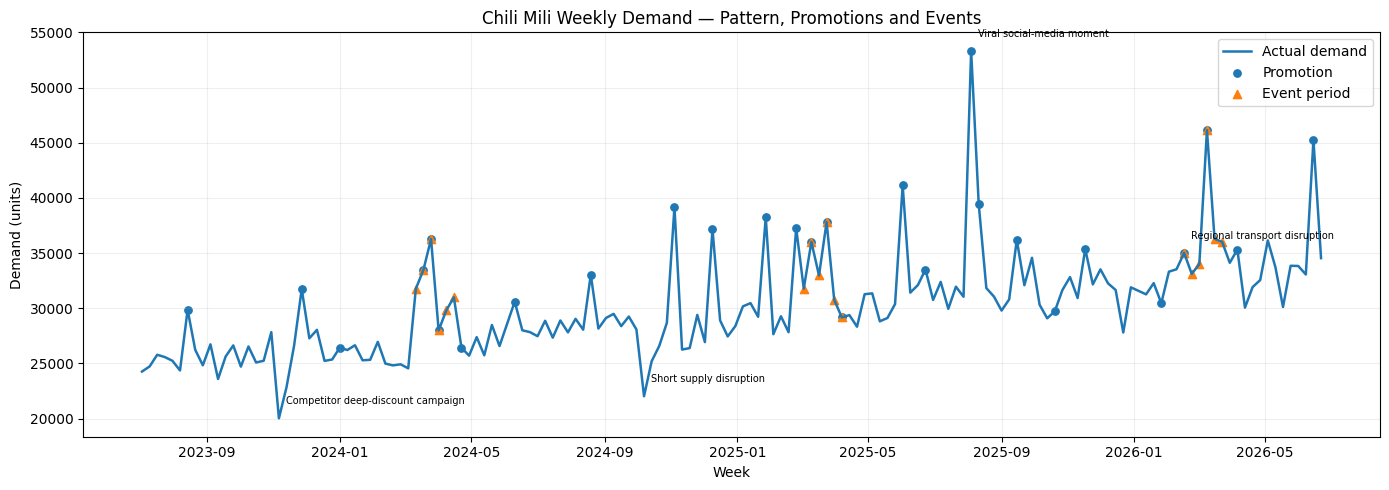

In [4]:
stats = df["Actual_Demand"].agg(["mean","median","std","min","max"])
stats["range"] = stats["max"] - stats["min"]
stats["CV_pct"] = stats["std"] / stats["mean"] * 100
display(stats.to_frame("Actual_Demand").round(2))

plt.figure(figsize=(14,5))
plt.plot(df["Week_Start_Date"], df["Actual_Demand"], label="Actual demand", linewidth=1.8)

promo = df[df["Promo_Flag"]==1]
plt.scatter(promo["Week_Start_Date"], promo["Actual_Demand"], label="Promotion", s=28)

events = df[df["Event_Flag"]==1]
plt.scatter(events["Week_Start_Date"], events["Actual_Demand"], label="Event period", marker="^", s=35)

for _, r in df[df["Exceptional_Event"].fillna("").astype(str).str.strip().ne("")].iterrows():
    plt.annotate(str(r["Exceptional_Event"]), (r["Week_Start_Date"],r["Actual_Demand"]),
                 xytext=(5,10), textcoords="offset points", fontsize=7)

plt.title("Chili Mili Weekly Demand — Pattern, Promotions and Events")
plt.ylabel("Demand (units)")
plt.xlabel("Week")
plt.legend()
plt.grid(alpha=.2)
plt.tight_layout()
plt.show()


### Demand Pattern Diagnosis

Chili Mili demand shows a gradually rising level over the three year synthetic history, with meaningful week to week variation around that level. Demand is not purely stable: promotion weeks and Ramadan/Eid-related event periods can create sharp temporary increases, while stockouts and exceptional disruptions can suppress observed sales. These effects return toward the underlying demand level rather than creating permanent structural shifts. The pattern therefore supports keeping a simple short-term benchmark while also testing seasonal/trend-capable approaches. Operationally, the main risk is not only average demand but the size of temporary peaks and disruptions, because these can create inventory shortages or excess commitments if the forecast is treated as certain.


## 5. Workstream B — Forecast Error Fundamentals

First evaluate the existing `Historical_Forecast`; this is separate from evaluating the new forecasting models.

Throughout the notebook:

\[
Error = Actual - Forecast
\]

**Positive error = under-forecasting. Negative error = over-forecasting.**


In [5]:
hist = df[["Week_Start_Date","Actual_Demand","Historical_Forecast"]].dropna().copy()
hist["Error"] = hist["Actual_Demand"] - hist["Historical_Forecast"]
hist["Absolute_Error"] = hist["Error"].abs()
hist["APE_pct"] = hist["Absolute_Error"] / hist["Actual_Demand"] * 100

def metric_values(actual, forecast):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    error = actual - forecast
    ae = np.abs(error)
    mad = ae.mean()
    mape = np.mean(ae / actual) * 100
    rmse = np.sqrt(np.mean(error**2))
    wape = ae.sum() / actual.sum() * 100
    bias = error.mean()
    rsfe = error.sum()
    ts = rsfe / mad if mad != 0 else np.nan
    return mad,mape,rmse,wape,bias,rsfe,ts

hm = metric_values(hist["Actual_Demand"], hist["Historical_Forecast"])
names = ["MAD / MAE","MAPE","RMSE","WAPE","Bias / MFE","RSFE","Tracking Signal"]
display(pd.DataFrame({"Metric":names,"Value":hm}).round(2))


,Metric,Value
0,MAD / MAE,2194.14
1,MAPE,7.00
2,RMSE,3253.62
3,WAPE,7.28
4,Bias / MFE,84.82
5,RSFE,13232.00
6,Tracking Signal,6.03


In [6]:
mad,mape,rmse,wape,bias,rsfe,ts = hm
direction = "under-forecasting" if bias > 0 else "over-forecasting"

print(f"MAD / MAE = {mad:,.0f} units — a typical historical weekly forecast miss is about {mad:,.0f} units.")
print(f"MAPE = {mape:.2f}% — demand is missed by about {mape:.2f}% on average. The near-zero limitation of MAPE is not material because demand stays well above zero.")
print(f"RMSE = {rmse:,.0f} units — large misses receive extra penalty, so this highlights exposure to unusually poor forecast weeks.")
print(f"WAPE = {wape:.2f}% — total absolute forecast error equals {wape:.2f}% of total actual volume.")
print(f"Bias / MFE = {bias:,.0f} units — the sign indicates overall {direction}.")
print(f"RSFE = {rsfe:,.0f} units — this is cumulative signed forecast error.")
print(f"Tracking Signal = {ts:.2f} — the sign indicates cumulative forecast direction; a large magnitude would trigger investigation for persistent drift.")

display(hist[["Week_Start_Date","Actual_Demand","Historical_Forecast","Error","Absolute_Error","APE_pct"]]
        .round({"APE_pct":2}).head(12))


MAD / MAE = 2,194 units — a typical historical weekly forecast miss is about 2,194 units.
MAPE = 7.00% — demand is missed by about 7.00% on average. The near-zero limitation of MAPE is not material because demand stays well above zero.
RMSE = 3,254 units — large misses receive extra penalty, so this highlights exposure to unusually poor forecast weeks.
WAPE = 7.28% — total absolute forecast error equals 7.28% of total actual volume.
Bias / MFE = 85 units — the sign indicates overall under-forecasting.
RSFE = 13,232 units — this is cumulative signed forecast error.
Tracking Signal = 6.03 — the sign indicates cumulative forecast direction; a large magnitude would trigger investigation for persistent drift.


,Week_Start_Date,Actual_Demand,Historical_Forecast,Error,Absolute_Error,APE_pct
0,2023-07-03,24266,24000,266,266,1.10
1,2023-07-10,24727,25396,-669,669,2.71
2,2023-07-17,25786,25444,342,342,1.33
3,2023-07-24,25579,23632,1947,1947,7.61
4,2023-07-31,25243,25787,-544,544,2.16
5,2023-08-07,24367,26374,-2007,2007,8.24
6,2023-08-14,29867,27710,2157,2157,7.22
7,2023-08-21,26237,25710,527,527,2.01
8,2023-08-28,24834,24875,-41,41,0.17
9,2023-09-04,26732,26337,395,395,1.48


## 6. Create the Mandatory 12-Week Holdout

The final 12 weeks are isolated **before model fitting**. All forecasting methods use the same training observations, same target series and same holdout period.


TRAIN:   2023-07-03 → 2026-03-30 | 144 weeks
HOLDOUT: 2026-04-06 → 2026-06-22 | 12 weeks


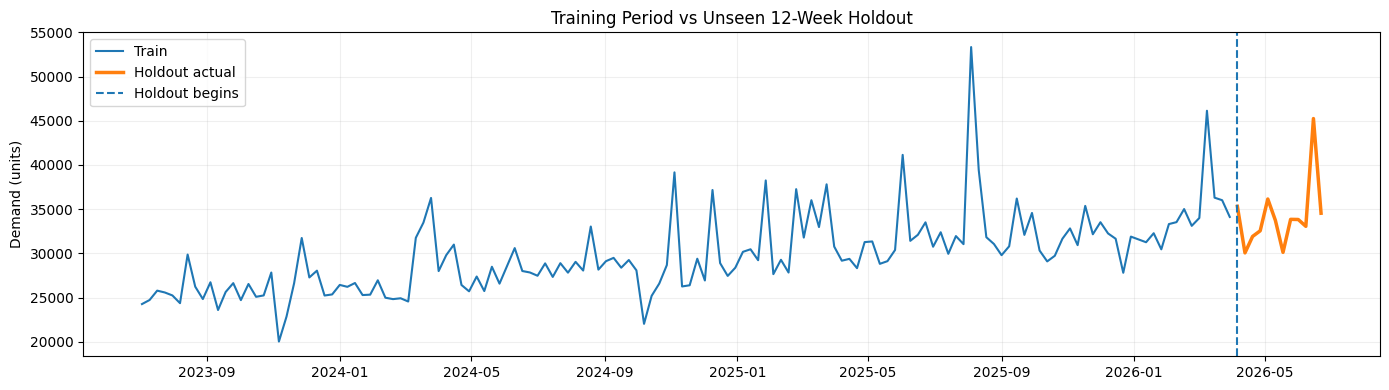

In [7]:
H = 12
train_df = df.iloc[:-H].copy()
test_df = df.iloc[-H:].copy()

print(f"TRAIN:   {train_df['Week_Start_Date'].min().date()} → {train_df['Week_Start_Date'].max().date()} | {len(train_df)} weeks")
print(f"HOLDOUT: {test_df['Week_Start_Date'].min().date()} → {test_df['Week_Start_Date'].max().date()} | {len(test_df)} weeks")

plt.figure(figsize=(14,4))
plt.plot(train_df["Week_Start_Date"],train_df["Actual_Demand"],label="Train")
plt.plot(test_df["Week_Start_Date"],test_df["Actual_Demand"],label="Holdout actual",linewidth=2.5)
plt.axvline(test_df["Week_Start_Date"].iloc[0],linestyle="--",label="Holdout begins")
plt.title("Training Period vs Unseen 12-Week Holdout")
plt.ylabel("Demand (units)")
plt.legend()
plt.grid(alpha=.2)
plt.tight_layout()
plt.show()


## 7. Workstream C — Build Forecasting Models

Models tested:

1. Naive baseline  
2. 52-week Seasonal Naive  
3. Recursive 4-week Moving Average  
4. Simple Exponential Smoothing, α = 0.3  
5. Simple Exponential Smoothing, α = 0.6  
6. Holt-Winters trend + 52-week seasonality  
7. Event-adjusted trend model

The moving average is recursive: once the holdout starts, it uses its own previous forecasts rather than revealing actual holdout demand.


In [8]:
# Naive
naive_fc = np.repeat(train_df["Actual_Demand"].iloc[-1], H)

# Seasonal Naive: same approximate week one year earlier
seasonal_naive_fc = train_df["Actual_Demand"].iloc[-52:-52+H].to_numpy()

# Recursive 4-week Moving Average
history = list(train_df["Actual_Demand"].astype(float))
ma4_fc = []
for _ in range(H):
    pred = np.mean(history[-4:])
    ma4_fc.append(pred)
    history.append(pred)
ma4_fc = np.array(ma4_fc)

# SES
ses03 = SimpleExpSmoothing(train_df["Actual_Demand"], initialization_method="estimated").fit(
    smoothing_level=.3, optimized=False)
ses06 = SimpleExpSmoothing(train_df["Actual_Demand"], initialization_method="estimated").fit(
    smoothing_level=.6, optimized=False)
ses03_fc = np.asarray(ses03.forecast(H))
ses06_fc = np.asarray(ses06.forecast(H))

# Holt-Winters
hw = ExponentialSmoothing(
    train_df["Actual_Demand"], trend="add", seasonal="add",
    seasonal_periods=52, initialization_method="estimated"
).fit(optimized=True)
hw_fc = np.asarray(hw.forecast(H))

# Event-adjusted trend model.
# Event_Flag is treated as a known calendar/planning input; holdout Actual_Demand is never used.
Xtr = pd.DataFrame({
    "Trend":np.arange(len(train_df)),
    "Event_Flag":train_df["Event_Flag"].to_numpy()
})
Xtr = sm.add_constant(Xtr)
event_model = sm.OLS(train_df["Actual_Demand"].to_numpy(),Xtr).fit()

Xte = pd.DataFrame({
    "Trend":np.arange(len(train_df),len(train_df)+H),
    "Event_Flag":test_df["Event_Flag"].to_numpy()
})
Xte = sm.add_constant(Xte,has_constant="add")
event_fc = np.asarray(event_model.predict(Xte))

forecasts = {
    "Naive":naive_fc,
    "Seasonal Naive (52w)":seasonal_naive_fc,
    "4-week MA":ma4_fc,
    "SES alpha=0.3":ses03_fc,
    "SES alpha=0.6":ses06_fc,
    "Holt-Winters":hw_fc,
    "Event-adjusted Trend":event_fc
}


### Why an Event-adjusted model?

Standard Holt-Winters models level, trend and repeating seasonality but does not directly accept an exogenous `Event_Flag`. The additional event-adjusted trend model tests whether a known event calendar adds forecasting value. Its event coefficient is interpreted as an **association**, not causal proof.


In [9]:
actual = test_df["Actual_Demand"].to_numpy()
rows = []

for model,fc in forecasts.items():
    mad,mape,rmse,wape,bias,rsfe,ts = metric_values(actual,fc)
    if abs(ts) < 4:
        comment = "Bias controlled; credible for short-term planning."
    else:
        comment = "Directional drift is material; investigate before use."
    rows.append([model,mad,mape,rmse,wape,bias,rsfe,ts,comment])

comparison = pd.DataFrame(rows,columns=[
    "Model","MAD","MAPE","RMSE","WAPE","Bias / MFE","RSFE","Tracking Signal","Managerial comment"
]).sort_values(["WAPE","RMSE"]).reset_index(drop=True)

display(comparison.round(2))
print("Winner by holdout WAPE:", comparison.iloc[0]["Model"])


,Model,MAD,MAPE,RMSE,WAPE,Bias / MFE,RSFE,Tracking Signal,Managerial comment
0,Naive,2385.33,6.61,3772.52,6.98,75.83,910.00,0.38,Bias controlled; credible for short-term plann...
1,Event-adjusted Trend,2466.42,6.90,3688.38,7.21,-173.65,-2083.75,-0.84,Bias controlled; credible for short-term plann...
2,Holt-Winters,2873.53,8.19,4126.35,8.40,-489.32,-5871.79,-2.04,Bias controlled; credible for short-term plann...
3,SES alpha=0.6,2873.71,8.26,3912.85,8.40,-1041.25,-12495.02,-4.35,Directional drift is material; investigate bef...
4,SES alpha=0.3,3304.37,9.64,4139.84,9.66,-1706.48,-20477.74,-6.20,Directional drift is material; investigate bef...
5,4-week MA,3734.61,10.93,4338.96,10.92,-2246.98,-26963.75,-7.22,Directional drift is material; investigate bef...
6,Seasonal Naive (52w),4082.08,11.23,5344.77,11.94,2863.92,34367.00,8.42,Directional drift is material; investigate bef...


Winner by holdout WAPE: Naive


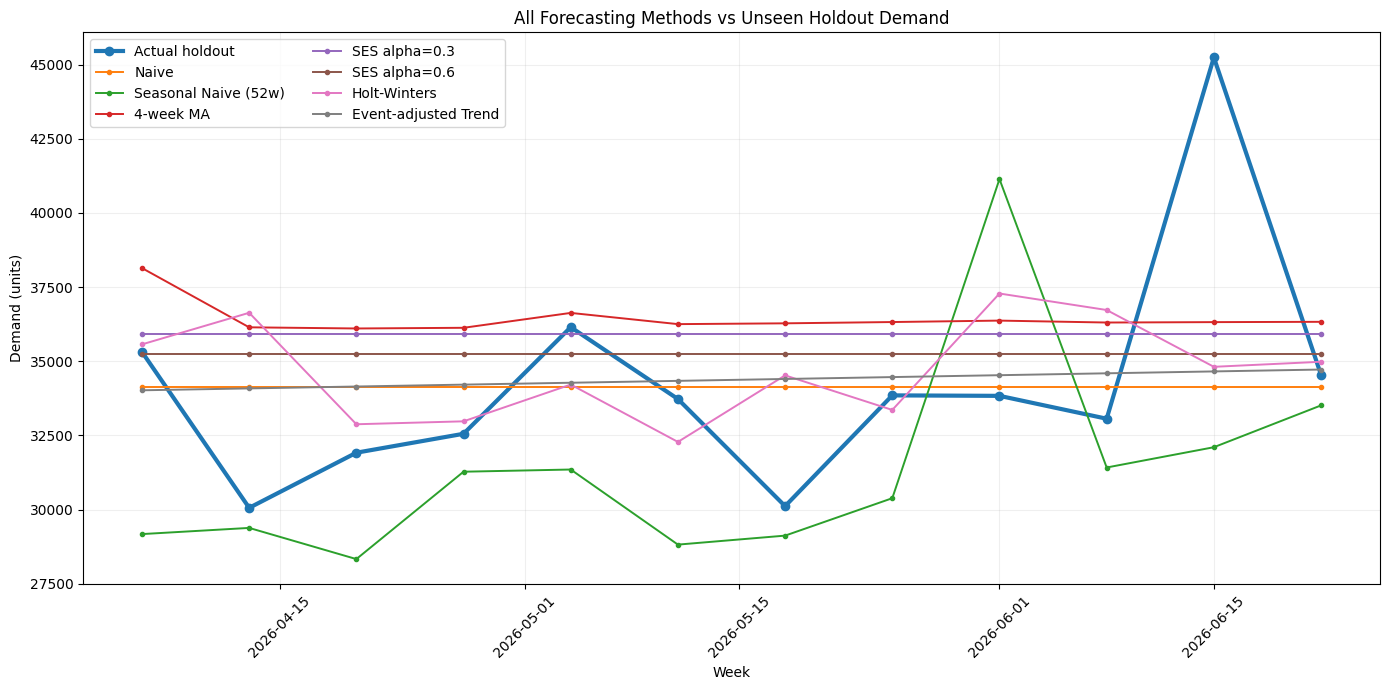

In [10]:
plt.figure(figsize=(14,7))
plt.plot(test_df["Week_Start_Date"],actual,marker="o",linewidth=3,label="Actual holdout")
for model,fc in forecasts.items():
    plt.plot(test_df["Week_Start_Date"],fc,marker=".",linewidth=1.4,label=model)
plt.title("All Forecasting Methods vs Unseen Holdout Demand")
plt.xlabel("Week")
plt.ylabel("Demand (units)")
plt.legend(ncol=2)
plt.grid(alpha=.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Mandatory Holdout Validation

**TRAIN → FORECAST HELD-OUT PERIOD → REVEAL ACTUAL → MEASURE ERROR → DIAGNOSE**

The winning model is selected from unseen holdout performance, sensible behavior and acceptable directional bias not because it is the most sophisticated.


In [11]:
best_model = comparison.iloc[0]["Model"]
best_fc = forecasts[best_model]

validation = test_df[[
    "Week_Start_Date","Actual_Demand","Promo_Flag","Promo_Depth",
    "Event_Flag","Stockout_Flag","Exceptional_Event"
]].copy()

validation["Forecast"] = best_fc
validation["Error"] = validation["Actual_Demand"] - validation["Forecast"]
validation["Absolute_Error"] = validation["Error"].abs()
validation["APE_pct"] = validation["Absolute_Error"]/validation["Actual_Demand"]*100

def diagnose(r):
    if r["Stockout_Flag"] == 1:
        return "Stockout / observed-sales constraint"
    if r["Promo_Flag"] == 1:
        return f"Promotion effect ({r['Promo_Depth']:.0f}% depth)"
    if r["Event_Flag"] == 1:
        return "Calendar / event effect"
    if pd.notna(r["Exceptional_Event"]) and str(r["Exceptional_Event"]).strip():
        return "Exceptional business event"
    return "Model weakness or unpredictable weekly variation"

validation["Diagnosis"] = validation.apply(diagnose,axis=1)
top5 = validation.nlargest(5,"Absolute_Error").copy()
top5.insert(0,"Rank",range(1,6))

display(top5[[
    "Rank","Week_Start_Date","Actual_Demand","Forecast","Error",
    "Absolute_Error","APE_pct","Promo_Flag","Promo_Depth",
    "Event_Flag","Stockout_Flag","Diagnosis"
]].round(2))


,Rank,Week_Start_Date,Actual_Demand,Forecast,Error,Absolute_Error,APE_pct,Promo_Flag,Promo_Depth,Event_Flag,Stockout_Flag,Diagnosis
154,1,2026-06-15,45245,34121,11124,11124,24.59,1,20,0,0,Promotion effect (20% depth)
145,2,2026-04-13,30057,34121,-4064,4064,13.52,0,0,0,0,Model weakness or unpredictable weekly variation
150,3,2026-05-18,30114,34121,-4007,4007,13.31,0,0,0,0,Model weakness or unpredictable weekly variation
146,4,2026-04-20,31916,34121,-2205,2205,6.91,0,0,0,0,Model weakness or unpredictable weekly variation
148,5,2026-05-04,36149,34121,2028,2028,5.61,0,0,0,0,Model weakness or unpredictable weekly variation


In [12]:
for _,r in top5.iterrows():
    direction = "under-forecast" if r["Error"] > 0 else "over-forecast"
    print(f"{int(r['Rank'])}. {r['Week_Start_Date'].date()}: {direction} by "
          f"{abs(r['Error']):,.0f} units ({r['APE_pct']:.1f}%). "
          f"Diagnosis: {r['Diagnosis']}.")


1. 2026-06-15: under-forecast by 11,124 units (24.6%). Diagnosis: Promotion effect (20% depth).
2. 2026-04-13: over-forecast by 4,064 units (13.5%). Diagnosis: Model weakness or unpredictable weekly variation.
3. 2026-05-18: over-forecast by 4,007 units (13.3%). Diagnosis: Model weakness or unpredictable weekly variation.
4. 2026-04-20: over-forecast by 2,205 units (6.9%). Diagnosis: Model weakness or unpredictable weekly variation.
5. 2026-05-04: under-forecast by 2,028 units (5.6%). Diagnosis: Model weakness or unpredictable weekly variation.


### Leakage Audit

The final 12 weeks were separated before fitting. Every forecasting model was fitted only on the earlier training period. Holdout `Actual_Demand` was revealed only after forecasts had been generated and was used solely for evaluation.

The recursive moving-average model uses its own previous forecasts rather than holdout actual values. The event-adjusted model uses `Event_Flag` as a known planning/calendar input, not holdout demand.

Accuracy is not suspiciously perfect: meaningful forecast errors remain, including promotion-related misses. **No holdout actual demand was used to train or recursively update the models.**


## 9. Driver Analysis — What Is Associated With Demand?

OLS is used to examine associations between demand and business drivers. Coefficients are **not** interpreted as causal effects.


In [13]:
reg_df = train_df.copy()
X = reg_df[["Price","Promo_Depth","Event_Flag","Distribution_Points","Stockout_Flag"]]
X = sm.add_constant(X)
y = reg_df["Actual_Demand"]

reg = sm.OLS(y,X).fit()
print(reg.summary())

driver_table = pd.DataFrame({
    "Coefficient":reg.params,
    "p_value":reg.pvalues
})
display(driver_table.round(4))


                            OLS Regression Results                            
Dep. Variable:          Actual_Demand   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     73.98
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           2.49e-37
Time:                        10:08:48   Log-Likelihood:                -1320.7
No. Observations:                 144   AIC:                             2653.
Df Residuals:                     138   BIC:                             2671.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -1.526e+04   3

,Coefficient,p_value
const,-15264.0813,0.0000
Price,1.4353,0.6984
Promo_Depth,467.8251,0.0000
Event_Flag,2342.6422,0.0003
Distribution_Points,3.0366,0.0016
Stockout_Flag,-6974.7971,0.0000


### Regression interpretation and caveat

Interpret statistically supported coefficients as **associations while holding the included variables constant**. A positive promotion or event coefficient is consistent with higher demand during those conditions; a negative stockout coefficient is consistent with constrained observed sales. If Price is statistically insignificant, do not claim that price causes demand to rise or fall in this model.

Potential omitted/confounding factors include competitor promotions, advertising intensity, retailer execution, weather, purchasing power and store-level availability.


## 10. Stress Testing

Validation asks whether the model predicted unseen actual outcomes. Stress testing asks whether the **management decision remains sensible if future conditions differ from the base forecast**.


In [14]:
# Refit the selected forecasting logic on all available observations for the NEXT 12-week operational forecast.
# This keeps model selection (holdout) separate from future deployment.

future_dates = pd.date_range(df["Week_Start_Date"].max()+pd.Timedelta(weeks=1), periods=12, freq="W-MON")

if best_model == "Naive":
    future_fc = np.repeat(df["Actual_Demand"].iloc[-1],12)
elif best_model == "Seasonal Naive (52w)":
    future_fc = df["Actual_Demand"].iloc[-52:-40].to_numpy()
elif best_model == "4-week MA":
    hist2 = list(df["Actual_Demand"].astype(float))
    vals=[]
    for _ in range(12):
        p=np.mean(hist2[-4:]); vals.append(p); hist2.append(p)
    future_fc=np.array(vals)
elif best_model.startswith("SES alpha=0.3"):
    m=SimpleExpSmoothing(df["Actual_Demand"],initialization_method="estimated").fit(smoothing_level=.3,optimized=False)
    future_fc=np.asarray(m.forecast(12))
elif best_model.startswith("SES alpha=0.6"):
    m=SimpleExpSmoothing(df["Actual_Demand"],initialization_method="estimated").fit(smoothing_level=.6,optimized=False)
    future_fc=np.asarray(m.forecast(12))
elif best_model == "Holt-Winters":
    m=ExponentialSmoothing(df["Actual_Demand"],trend="add",seasonal="add",seasonal_periods=52,initialization_method="estimated").fit()
    future_fc=np.asarray(m.forecast(12))
else:
    # For an event-adjusted future forecast, future event calendar must be specified.
    # Conservative default: no special event flag unless management provides the future calendar.
    Xa=sm.add_constant(pd.DataFrame({
        "Trend":np.arange(len(df)),
        "Event_Flag":df["Event_Flag"].to_numpy()
    }))
    m=sm.OLS(df["Actual_Demand"].to_numpy(),Xa).fit()
    Xf=sm.add_constant(pd.DataFrame({
        "Trend":np.arange(len(df),len(df)+12),
        "Event_Flag":np.zeros(12,dtype=int)
    }),has_constant="add")
    future_fc=np.asarray(m.predict(Xf))

base_total = future_fc.sum()

stress = pd.DataFrame({
    "Scenario":["Downside -20%","Downside -10%","Base","Upside +10%","Upside +20%","Event shock +15%"],
    "12-week Demand":[base_total*.80,base_total*.90,base_total,base_total*1.10,base_total*1.20,base_total*1.15]
})
stress["Difference vs Base"] = stress["12-week Demand"] - base_total
display(stress.round(0))

# Illustrative operational constraint: compare an assumed 110% of base capacity ceiling.
capacity = base_total*1.10
print(f"Illustrative 12-week capacity ceiling (110% of base): {capacity:,.0f} units")
print(f"Under +20% upside, capacity shortfall would be approximately {max(0,base_total*1.20-capacity):,.0f} units.")


,Scenario,12-week Demand,Difference vs Base
0,Downside -20%,331603.0,-82901.0
1,Downside -10%,373054.0,-41450.0
2,Base,414504.0,0.0
3,Upside +10%,455954.0,41450.0
4,Upside +20%,497405.0,82901.0
5,Event shock +15%,476680.0,62176.0


Illustrative 12-week capacity ceiling (110% of base): 455,954 units
Under +20% upside, capacity shortfall would be approximately 41,450 units.


### Operational Consequences of Stress Scenarios

The stress test evaluates whether the recommended 80/20 supply decision remains sensible when actual demand differs from the base forecast of **414,504 units**.

| Scenario | 12-Week Demand | Change vs Base | Operational Consequence |
|---|---:|---:|---|
| Downside −20% | 331,603 | −82,901 | Committing the full base forecast could create up to 82,901 units of excess inventory; the 80% initial commitment reduces this exposure. |
| Downside −10% | 373,054 | −41,450 | Lower demand creates inventory and working-capital exposure; management can delay part of the flexible quantity. |
| Base | 414,504 | — | Commit 331,603 units initially and retain 82,901 units as flexible supply. |
| Upside +20% | 497,405 | +82,901 | Additional supply would be required, increasing capacity and service-level risk. |
| Event Shock +15% | 476,680 | +62,176 | A stronger promotion/event spike could require approximately 62,176 additional units above the base forecast. |
| Operational Constraint | 497,405 demand vs. 455,954 capacity | 41,451-unit capacity gap | Under +20% demand with constrained capacity, approximately 41,450 units could be unavailable, creating shortage and service risk. |


### Is the Decision Still Sensible?

Yes. The **80/20 commitment strategy remains reasonably robust** under forecast uncertainty. Committing **331,603 units (80%)** initially limits excess-inventory and working-capital exposure if demand falls, while keeping **82,901 units (20%)** flexible provides room to respond to stronger-than-expected demand and promotion/event spikes.

However, the stress test also identifies an important limit. Under the +20% demand scenario, expected demand reaches **497,405 units**. If available capacity is limited to approximately **455,954 units**, this creates a capacity gap of about **41,450 units**. Management should therefore preserve flexible supplier or production capacity and reforecast if cumulative actual demand during the first two weeks differs from plan by more than **10%**.

## 11. Final Operational Decision

The winning model is chosen using the holdout. It is then **refitted/reapplied using all available history** to create the next 12-week operational forecast. This avoids the common error of treating the historical holdout forecast as the future planning horizon.


In [15]:
commit_share = 0.80
commit_now = base_total*commit_share
flexible = base_total-commit_now

print(f"Selected model: {best_model}")
print(f"Next 12-week expected demand: {base_total:,.0f} units")
print(f"Average planned weekly demand: {base_total/12:,.0f} units")
print(f"Commit now (80%): {commit_now:,.0f} units")
print(f"Keep flexible (20%): {flexible:,.0f} units")
print("Review trigger: reforecast if cumulative actual demand after the first two weeks differs from plan by more than 10%, or if Tracking Signal moves outside ±4.")

future_plan = pd.DataFrame({"Week_Start_Date":future_dates,"Forecast_Units":future_fc})
display(future_plan.round(0))


Selected model: Naive
Next 12-week expected demand: 414,504 units
Average planned weekly demand: 34,542 units
Commit now (80%): 331,603 units
Keep flexible (20%): 82,901 units
Review trigger: reforecast if cumulative actual demand after the first two weeks differs from plan by more than 10%, or if Tracking Signal moves outside ±4.


,Week_Start_Date,Forecast_Units
0,2026-06-29,34542
1,2026-07-06,34542
2,2026-07-13,34542
3,2026-07-20,34542
4,2026-07-27,34542
5,2026-08-03,34542
6,2026-08-10,34542
7,2026-08-17,34542
8,2026-08-24,34542
9,2026-08-31,34542


## 12. Executive Decision Summary

The recommendation should be interpreted as a forecast-informed supply plan, not a sales target. Based on the selected Naive model, the operational forecast for the next 12 weeks is 414,504 demand units, or approximately 34,542 units per week. The Naive model was selected based on its performance on the unseen 12-week holdout period, achieving a WAPE of 6.98% and a Tracking Signal of +0.38.
Management should initially commit approximately 80% of forecast demand (331,603 units) while keeping the remaining 20% (82,901 units) flexible. This flexibility is important because promotion and event weeks can generate substantially larger forecast errors than normal weeks.
The plan should be reviewed after the first two weeks. A reforecast should be triggered if cumulative actual demand differs from forecast by more than 10%, or if the Tracking Signal moves outside ±4. Promotion intensity, event timing, stockouts, and distribution coverage should also be monitored because the analysis indicates that these factors are associated with meaningful changes in observed demand.
